In [35]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph ,START, END 
from typing import TypedDict 
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import InMemorySaver
import operator 
from dotenv import load_dotenv
load_dotenv(override=True)
import os



In [36]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm_model=ChatGroq(model="llama-3.1-8b-instant")

In [37]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [38]:
def generate_joke(state: JokeState):
    prompt = f"write a joke for the topic {state["topic"]}"
    response = llm_model.invoke(prompt)

    return {'joke':response}

In [39]:
def geneate_explanation(state:JokeState):
    prompt = f"explain the joke {state["joke"]}"
    response = llm_model.invoke(prompt)

    return {'explanation':response}

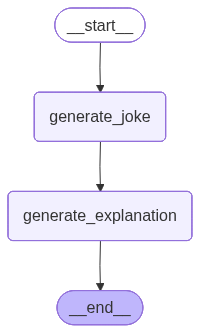

In [40]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", geneate_explanation)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

checkpointer = InMemorySaver()


workflow = graph.compile(checkpointer=checkpointer)
workflow


In [41]:
#creating a config to pass in the thread_id for the checkpointer , this will ensure that the state of this workflow execution is saved under this thread_id in the checkpointer

config1 = {'configurable': {"thread_id":1}}
workflow.invoke({'topic': 'dogs'}, config=config1)



{'topic': 'dogs',
 'joke': AIMessage(content='Why did the dog go to the vet?\n\nBecause he was feeling a little ruff.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 42, 'total_tokens': 61, 'completion_time': 0.020333892, 'completion_tokens_details': None, 'prompt_time': 0.003118638, 'prompt_tokens_details': None, 'queue_time': 0.079014101, 'total_time': 0.02345253}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb16-a371-7d33-a137-2ce24877f96e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 19, 'total_tokens': 61}),
 'explanation': AIMessage(content='The joke is a play on words. The phrase "feeling a little ruff" has a double meaning:\n\n1. **Puns on "ruff" and "rough"**: The word "ruff" can also be spelled as "rough", which is a common phrase

In [42]:
workflow.get_state(config1) 

StateSnapshot(values={'topic': 'dogs', 'joke': AIMessage(content='Why did the dog go to the vet?\n\nBecause he was feeling a little ruff.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 42, 'total_tokens': 61, 'completion_time': 0.020333892, 'completion_tokens_details': None, 'prompt_time': 0.003118638, 'prompt_tokens_details': None, 'queue_time': 0.079014101, 'total_time': 0.02345253}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb16-a371-7d33-a137-2ce24877f96e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 19, 'total_tokens': 61}), 'explanation': AIMessage(content='The joke is a play on words. The phrase "feeling a little ruff" has a double meaning:\n\n1. **Puns on "ruff" and "rough"**: The word "ruff" can also be spelled as "rough", which

In [ ]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'dogs', 'joke': AIMessage(content='Why did the dog go to the vet?\n\nBecause he was feeling a little ruff.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 42, 'total_tokens': 61, 'completion_time': 0.020333892, 'completion_tokens_details': None, 'prompt_time': 0.003118638, 'prompt_tokens_details': None, 'queue_time': 0.079014101, 'total_time': 0.02345253}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb16-a371-7d33-a137-2ce24877f96e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 19, 'total_tokens': 61}), 'explanation': AIMessage(content='The joke is a play on words. The phrase "feeling a little ruff" has a double meaning:\n\n1. **Puns on "ruff" and "rough"**: The word "ruff" can also be spelled as "rough", whic

In [45]:
config2 = {'configurable': {"thread_id":2}}
workflow.invoke({'topic': 'PIZZA'}, config=config2)


{'topic': 'PIZZA',
 'joke': AIMessage(content='Why did the pizza go to the doctor?\n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 44, 'total_tokens': 63, 'completion_time': 0.030810707, 'completion_tokens_details': None, 'prompt_time': 0.002499924, 'prompt_tokens_details': None, 'queue_time': 0.294438143, 'total_time': 0.033310631}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb1b-2097-70f2-bed8-91d537d40f04-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 19, 'total_tokens': 63}),
 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. Here\'s a breakdown of the joke:\n\n"Why did the pizza go to the doctor?" - This is the setup for the joke, asking the listener t

In [48]:
workflow.get_state(config2) 

StateSnapshot(values={'topic': 'PIZZA', 'joke': AIMessage(content='Why did the pizza go to the doctor?\n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 44, 'total_tokens': 63, 'completion_time': 0.030810707, 'completion_tokens_details': None, 'prompt_time': 0.002499924, 'prompt_tokens_details': None, 'queue_time': 0.294438143, 'total_time': 0.033310631}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb1b-2097-70f2-bed8-91d537d40f04-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 19, 'total_tokens': 63}), 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. Here\'s a breakdown of the joke:\n\n"Why did the pizza go to the doctor?" - This is the setup for the joke, as